# Projet end-to-end de ML pour la detection des fraudes à l'assurance automobile

Le dataset contient des informations sur les véhicules ainsi que les données liées aux contrats d'assurance (type de police, durée..)

L'objectif est de determiner si une demande d'indemnisation est frauduleuse ou non.

## Import des librairies

In [14]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

## Chargement du dataset



In [3]:
path = "input/fraud_oracle.csv"
df = pd.read_csv(path)



In [10]:
# Affichage des premières lignes
#print(df.head())

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [16]:
# EXPLORATION RAPIDE DES DONNEES
# Afficher la forme du dataset et les colonnes
print("\n")
print(f"Forme du dataset: {df.shape}")
print("\n")
print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")

# Explorer les types de données et les valeurs manquantes
print("\n")
print("\nTypes de données et valeurs manquantes:")
print(df.info())

print("\n")
print("Valeurs manquantes:")
print(df.isnull().sum())



Forme du dataset: (15420, 33)


Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'Polic

In [17]:
# 2.1 EDA - ANALYSE EXPLORATOIRE DÉTAILLÉE
print("\n=== ANALYSE EXPLORATOIRE (EDA) ===")

# Statistiques descriptives
print("Statistiques descriptives:")
print(df.describe())


=== ANALYSE EXPLORATOIRE (EDA) ===
Statistiques descriptives:
        WeekOfMonth  WeekOfMonthClaimed           Age  FraudFound_P  \
count  15420.000000        15420.000000  15420.000000  15420.000000   
mean       2.788586            2.693969     39.855707      0.059857   
std        1.287585            1.259115     13.492377      0.237230   
min        1.000000            1.000000      0.000000      0.000000   
25%        2.000000            2.000000     31.000000      0.000000   
50%        3.000000            3.000000     38.000000      0.000000   
75%        4.000000            4.000000     48.000000      0.000000   
max        5.000000            5.000000     80.000000      1.000000   

       PolicyNumber     RepNumber    Deductible  DriverRating          Year  
count  15420.000000  15420.000000  15420.000000  15420.000000  15420.000000  
mean    7710.500000      8.483268    407.704280      2.487808   1994.866472  
std     4451.514911      4.599948     43.950998      1.119453  

Text(0.5, 1.0, 'Matrice de Corrélation')

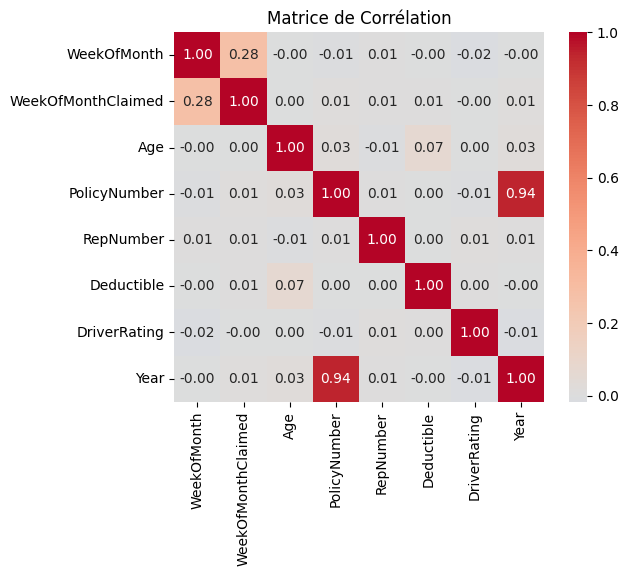

In [18]:
# Matrice de correlation
corr_matrix = df[num_colums].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matrice de Corrélation')